In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Device: Tesla T4


In [2]:
!pip install -q numpy pandas torch scikit-learn matplotlib seaborn opencv-python mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.5 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [4]:
from google.colab import files
uploaded = files.upload()
DATASET_PATH = list(uploaded.keys())[0]
print("Loaded:", DATASET_PATH)

Saving OH01_April_14_2022 - Raw Data.txt to OH01_April_14_2022 - Raw Data.txt
Loaded: OH01_April_14_2022 - Raw Data.txt


In [5]:
def load_eye_tracking_txt(path):
    return pd.read_csv(
        path,
        sep="\t",
        low_memory=False,
        na_values=["-", "NA"]
    )

df = load_eye_tracking_txt(DATASET_PATH)
print(df.shape)
df.head()

(80410, 40)


,RecordingTime [ms],Time of Day [h:m:s:ms],Trial,Stimulus,Export Start Trial Time [ms],Export End Trial Time [ms],Participant,Color,Tracking Ratio [%],Category Group,...,Gaze Vector Left Z,Video Time [h:m:s:ms],Annotation Name,Annotation Description,Annotation Tags,Mouse Position X [px],Mouse Position Y [px],Scroll Direction X,Scroll Direction Y,Content
0,358405.3,11:20:46:884,Trial001,NoImage,0.0,186123.4,OH01_Sham_1,Coral,98.8,Eye,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,358422.0,11:20:46:901,Trial001,NoImage,0.0,186123.4,OH01_Sham_1,Coral,98.8,Eye,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,358438.6,11:20:46:917,Trial001,NoImage,0.0,186123.4,OH01_Sham_1,Coral,98.8,Eye,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,358455.2,11:20:46:934,Trial001,NoImage,0.0,186123.4,OH01_Sham_1,Coral,98.8,Eye,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,358471.8,11:20:46:951,Trial001,NoImage,0.0,186123.4,OH01_Sham_1,Coral,98.8,Eye,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# ---------------------------------------------------------
# UPDATED PREPROCESSING & TRAINING DATA GENERATION
# ---------------------------------------------------------

# 1. Select ONLY the features available from a Webcam (X, Y for both eyes)
# We use 'Point of Regard' as proxies for Gaze X/Y
FEATURE_COLS = [
    "Point of Regard Left X [px]",
    "Point of Regard Left Y [px]",
    "Point of Regard Right X [px]",
    "Point of Regard Right Y [px]"
]

# Clean NaNs
df_clean = df.dropna(subset=FEATURE_COLS).copy()

# 2. Define Windowing Logic with Normalization
def create_windows(values, label, window_size, stride):
    X_wins, y_wins = [], []

    # Pre-calculate Min/Max for 0-1 Normalization (Matching MediaPipe)
    # This converts pixels (e.g., 800px) to ratio (e.g., 0.45)
    v_min = values.min(axis=0)
    v_max = values.max(axis=0)
    # Avoid division by zero
    v_range = v_max - v_min
    v_range[v_range == 0] = 1.0

    # Normalize entire sequence to 0-1
    values_norm = (values - v_min) / v_range

    for i in range(0, len(values_norm) - window_size, stride):
        w = values_norm[i:i+window_size]
        X_wins.append(w)
        y_wins.append(label)
    return X_wins, y_wins

X_all, y_all = [], []
WINDOW = 300
STRIDE = 100

print("Processing participants...")

# 3. Iterate and Process
for participant, sub_df in df_clean.groupby("Participant"):
    values = sub_df[FEATURE_COLS].values

    # --- CRITICAL FIX: Correct Labels ---
    # Sham = 0 (Control), Others = 1 (Parkinson's)
    if "Sham" in str(participant):
        label = 0
    else:
        label = 1

    X_p, y_p = create_windows(values, label, WINDOW, STRIDE)
    X_all.extend(X_p)
    y_all.extend(y_p)

X = np.array(X_all)
y = np.array(y_all)

print(f"Final Dataset Shape: {X.shape}")
print(f"Class Distribution (0=Control, 1=PD): {np.bincount(y)}")

# 4. Prepare Loaders (Input dim is now 4)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train)),
    batch_size=32, shuffle=True
)

test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test)),
    batch_size=64
)

Processing participants...
Final Dataset Shape: (607, 300, 4)
Class Distribution (0=Control, 1=PD): [382 225]


In [7]:
# ---------------------------------------------------------
# RE-INITIALIZE MODEL WITH INPUT DIM = 4
# ---------------------------------------------------------
class NeuroVisionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, 128,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1])

# Input dimension is now 4 (Lx, Ly, Rx, Ry)
model = NeuroVisionModel(input_dim=4).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [8]:
train_losses, test_accuracies = [], []

for epoch in range(25):
    model.train()
    loss_sum = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        loss = criterion(model(xb), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()

    train_losses.append(loss_sum)

    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            preds.extend(model(xb).argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    acc = accuracy_score(trues, preds)
    test_accuracies.append(acc)

    print(f"Epoch {epoch+1} | Loss: {loss_sum:.2f} | Accuracy: {acc:.3f}")

Epoch 1 | Loss: 10.56 | Accuracy: 0.631
Epoch 2 | Loss: 8.49 | Accuracy: 0.795
Epoch 3 | Loss: 7.79 | Accuracy: 0.811
Epoch 4 | Loss: 8.30 | Accuracy: 0.730
Epoch 5 | Loss: 8.53 | Accuracy: 0.680
Epoch 6 | Loss: 7.59 | Accuracy: 0.844
Epoch 7 | Loss: 7.04 | Accuracy: 0.877
Epoch 8 | Loss: 7.43 | Accuracy: 0.754
Epoch 9 | Loss: 11.10 | Accuracy: 0.754
Epoch 10 | Loss: 9.22 | Accuracy: 0.705
Epoch 11 | Loss: 9.43 | Accuracy: 0.631
Epoch 12 | Loss: 10.38 | Accuracy: 0.631
Epoch 13 | Loss: 9.70 | Accuracy: 0.730
Epoch 14 | Loss: 9.73 | Accuracy: 0.730
Epoch 15 | Loss: 9.05 | Accuracy: 0.730
Epoch 16 | Loss: 9.03 | Accuracy: 0.730
Epoch 17 | Loss: 8.96 | Accuracy: 0.730
Epoch 18 | Loss: 8.59 | Accuracy: 0.730
Epoch 19 | Loss: 8.35 | Accuracy: 0.869
Epoch 20 | Loss: 7.23 | Accuracy: 0.852
Epoch 21 | Loss: 7.78 | Accuracy: 0.844
Epoch 22 | Loss: 7.06 | Accuracy: 0.877
Epoch 23 | Loss: 6.79 | Accuracy: 0.877
Epoch 24 | Loss: 6.48 | Accuracy: 0.893
Epoch 25 | Loss: 6.55 | Accuracy: 0.893


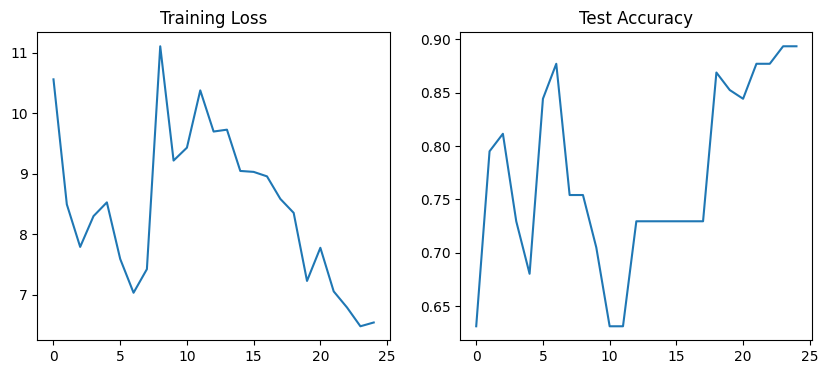

In [9]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")

plt.subplot(1,2,2)
plt.plot(test_accuracies)
plt.title("Test Accuracy")

plt.show()

In [18]:
uploaded_video = files.upload()
VIDEO_PATH = list(uploaded_video.keys())[0]

Saving Parkinson_s_Eye_Movement_Video_Generation.mp4 to Parkinson_s_Eye_Movement_Video_Generation.mp4


In [21]:
# Download MediaPipe Face Mesh model if needed
!wget -q -O face_landmarker.task https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task

In [22]:
# ---------------------------------------------------------
# USE THIS FOR INFERENCE ON VIDEO
# ---------------------------------------------------------
import cv2
import mediapipe as mp
import numpy as np
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

def extract_gaze_from_video(video_path):
    # Initialize FaceLandmarker with VIDEO mode
    base_options = python.BaseOptions(model_asset_path='face_landmarker.task')
    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5,
        running_mode=vision.RunningMode.VIDEO
    )

    # Create the detector
    detector = vision.FaceLandmarker.create_from_options(options)

    cap = cv2.VideoCapture(video_path)
    gaze_data = []

    # Get FPS for timestamp calculation
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0: fps = 30.0

    frame_index = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert to RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Create MediaPipe Image
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

        # Calculate timestamp in milliseconds
        timestamp_ms = int((frame_index / fps) * 1000)

        # Detect (using detect_for_video)
        detection_result = detector.detect_for_video(mp_image, timestamp_ms)

        if detection_result.face_landmarks:
            landmarks = detection_result.face_landmarks[0]

            # Iris indices (Left: 468, Right: 473)
            l_iris = landmarks[468]
            r_iris = landmarks[473]

            # Append normalized coordinates [Lx, Ly, Rx, Ry]
            gaze_data.append([l_iris.x, l_iris.y, r_iris.x, r_iris.y])

        frame_index += 1

    cap.release()
    detector.close()
    return np.array(gaze_data)

def predict_from_video(video_path):
    # 1. Extract
    gaze = extract_gaze_from_video(video_path)

    if len(gaze) == 0:
        print("No gaze detected in video.")
        return 0.0

    # 2. Pad or truncate to WINDOW size
    # If video is shorter than WINDOW (300), we pad with the mean value
    # If longer, we take the middle 300 frames
    target_len = 300
    current_len = len(gaze)

    if current_len < target_len:
        # Padding
        pad_len = target_len - current_len
        # Pad with the last known gaze position (holding gaze)
        if current_len > 0:
            last_val = gaze[-1]
            padding = np.tile(last_val, (pad_len, 1))
            padded_gaze = np.vstack([gaze, padding])
        else:
            return 0.0
    else:
        # Truncating (take center crop)
        start = (current_len - target_len) // 2
        padded_gaze = gaze[start : start + target_len]

    # 3. Predict (No extra normalization needed as MediaPipe is already 0-1)
    model.eval()
    with torch.no_grad():
        tensor_in = torch.tensor(padded_gaze).unsqueeze(0).float().to(DEVICE)
        # Logits -> Softmax -> Probability of Class 1
        prob = torch.softmax(model(tensor_in), dim=1)[0, 1].item()

    return prob

In [23]:
def neurovision_report(risk):
    print("\n🧠 NeuroVision Diagnostic Report")
    print("--------------------------------")
    print(f"Risk Score: {risk:.2f}")

    if risk > 0.75:
        print("Classification: HIGH RISK")
        print("Recommendation: Neurology consult advised")
    elif risk > 0.45:
        print("Classification: MODERATE RISK")
        print("Recommendation: Periodic monitoring")
    else:
        print("Classification: LOW RISK")
        print("Recommendation: No immediate concern")

    print("--------------------------------")

In [24]:
risk = predict_from_video(VIDEO_PATH)
neurovision_report(risk)


🧠 NeuroVision Diagnostic Report
--------------------------------
Risk Score: 0.20
Classification: LOW RISK
Recommendation: No immediate concern
--------------------------------
